# EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

STOCK_TICKERS = [
    'AAPL', 'MSFT', 'ADBE', 'CSCO', 
    'JPM', 'BAC', 'GS', 'AXP',     
    'PG', 'KO', 'PEP',            
    'XOM', 'CVX',                 
    'JNJ', 'PFE', 'MRK',          
    'AMZN', 'NKE', 'TSLA',        
    'T', 'VZ', 'TMUS',             
    'CAT', 'DE',                 
    'APD', 'LIN',                  
    'PLD', 'AMT', 'EQIX'          
]
START_DATE = '2010-01-01'
END_DATE = '2020-12-31'

data = yf.download(STOCK_TICKERS, start=START_DATE, end=END_DATE)['Close']

data = data.fillna(method='ffill').fillna(method='bfill')

data.to_excel('stock_data.xlsx', sheet_name='Stock Prices')

returns = data.pct_change().dropna()
n_assets = len(STOCK_TICKERS)

returns

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  29 of 29 completed
/var/folders/4m/44lhvkwx4nvgyd60ttsx1vk00000gn/T/ipykernel_46256/188534717.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')


Ticker,AAPL,ADBE,AMT,AMZN,APD,AXP,BAC,CAT,CSCO,CVX,...,NKE,PEP,PFE,PG,PLD,T,TMUS,TSLA,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,0.001729,0.016446,0.016567,0.005900,-0.008297,-0.002200,0.032505,0.011956,-0.004456,0.007083,...,0.003979,0.012084,-0.014263,0.000327,0.014584,-0.004899,0.002509,0.000000,0.001803,0.003905
2010-01-06,-0.015906,-0.002122,0.005206,-0.018116,-0.008245,0.016165,0.011728,0.003038,-0.006509,0.000126,...,-0.006097,-0.010003,-0.003215,-0.004743,-0.008936,-0.009823,-0.067585,0.000000,-0.028754,0.008643
2010-01-07,-0.001849,-0.019405,-0.002703,-0.017013,-0.005747,0.016219,0.032947,0.004038,0.004504,-0.003768,...,0.009814,-0.006356,-0.003763,-0.005423,0.008232,-0.011228,0.009396,0.000000,-0.005953,-0.003141
2010-01-08,0.006648,-0.005422,0.002032,0.027077,0.006394,-0.000715,-0.008861,0.011229,0.005300,0.001765,...,-0.001974,-0.003280,0.008095,-0.001322,-0.002722,-0.007326,-0.055851,0.000000,0.000630,-0.004012
2010-01-11,-0.008822,-0.013083,-0.009013,-0.024041,0.018328,-0.011442,0.008940,0.062811,-0.002838,0.017742,...,-0.012325,-0.001152,0.008030,-0.003970,0.001170,-0.004797,0.012676,0.000000,0.004095,0.011220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-23,-0.006976,-0.014400,-0.014014,-0.006627,0.008485,0.020951,0.028758,0.010421,-0.006937,0.015766,...,-0.004844,0.002708,0.019053,-0.001538,-0.014951,0.012324,-0.000151,0.008808,-0.000509,0.012852
2020-12-24,0.007712,0.005937,0.011379,-0.003949,0.007887,0.003420,-0.002995,0.006389,0.003605,-0.004201,...,-0.001129,0.004501,-0.004540,0.010122,0.010916,-0.002087,0.005218,0.024443,-0.002035,-0.004070
2020-12-28,0.035766,-0.001820,0.011068,0.035071,0.000931,0.008607,0.005674,-0.006627,0.008532,-0.005039,...,0.005861,0.012754,-0.012074,0.006971,0.010078,-0.004880,0.000602,0.002901,0.002379,0.003366


## Stats

In [2]:
import matplotlib.pyplot as plt

def display_summary_statistics(returns):
    summary_stats = pd.DataFrame({
        "Mean Return (Annualized)": returns.mean() * 252,
        "Std Dev (Annualized)": returns.std() * np.sqrt(252),
        "Min Return": returns.min(),
        "Max Return": returns.max()
    })
    summary_stats.index.name = "Stock"
    summary_stats = summary_stats.round(3)
    print("\nDescriptive Statistics:")
    print(summary_stats)
    return summary_stats

def save_dataframe_as_image(df, filename='summary_statistics.png'):
    fig, ax = plt.subplots(figsize=(10, 4))  
    ax.axis('tight')  
    ax.axis('off')    
    
    table = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2) 
    plt.savefig(filename, dpi=300, bbox_inches='tight')  
    plt.close(fig)  

summary_stats = display_summary_statistics(returns)  
save_dataframe_as_image(summary_stats, filename='summary_statistics.png')  



Descriptive Statistics:
       Mean Return (Annualized)  Std Dev (Annualized)  Min Return  Max Return
Stock                                                                        
AAPL                      0.314                 0.283      -0.129       0.120
ADBE                      0.283                 0.304      -0.190       0.177
AMT                       0.191                 0.235      -0.152       0.122
AMZN                      0.342                 0.317      -0.127       0.157
APD                       0.168                 0.236      -0.126       0.137
AXP                       0.155                 0.291      -0.148       0.219
BAC                       0.135                 0.357      -0.203       0.178
CAT                       0.173                 0.292      -0.143       0.103
CSCO                      0.116                 0.271      -0.162       0.160
CVX                       0.083                 0.272      -0.221       0.227
DE                        0.202        

## Correlation 

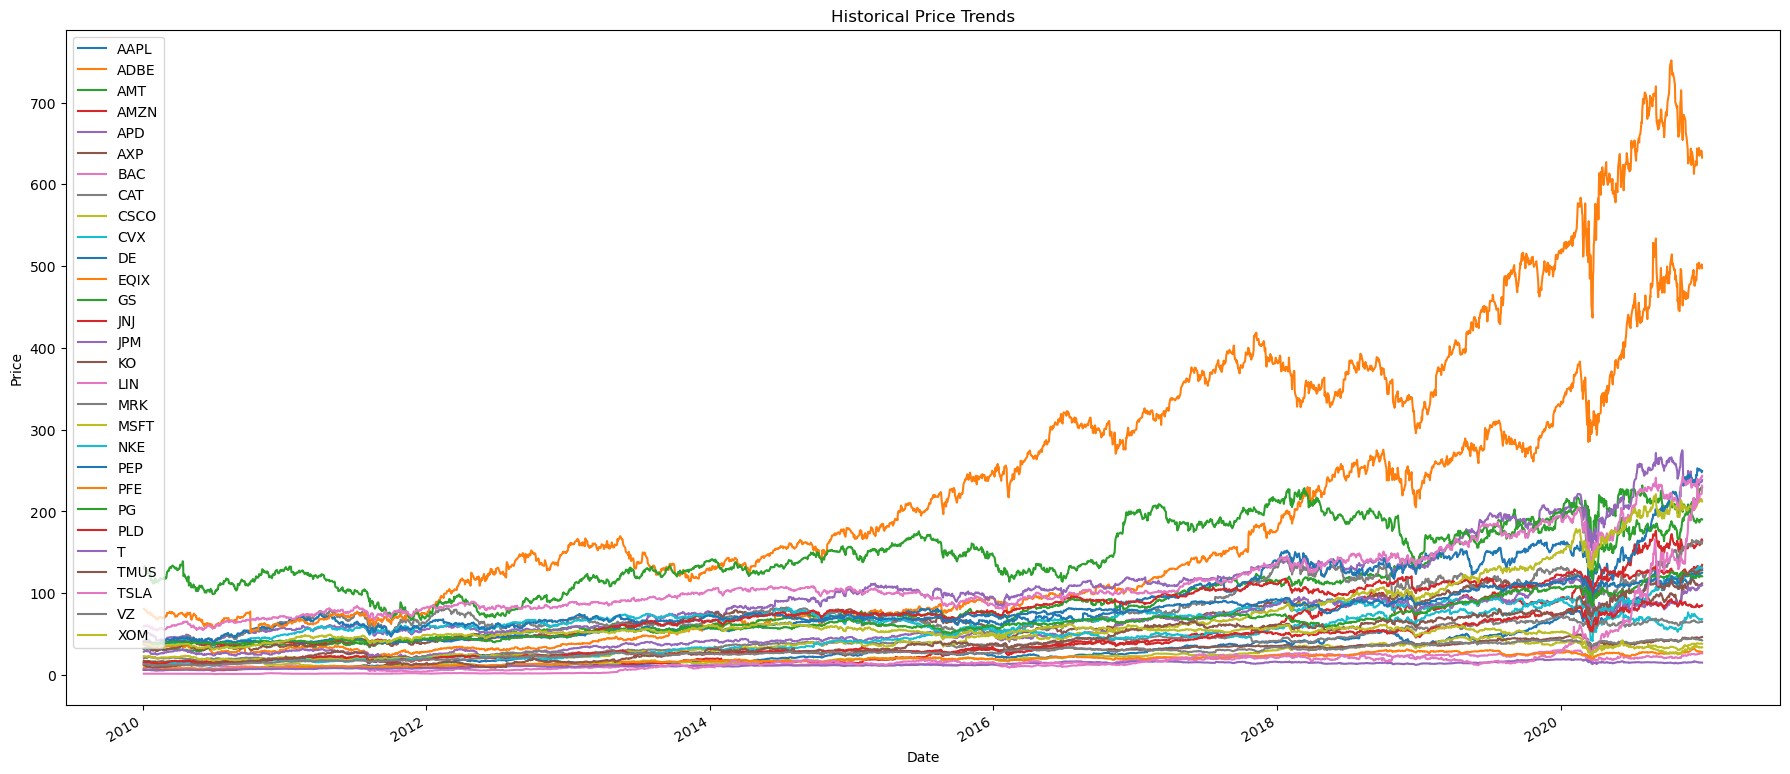

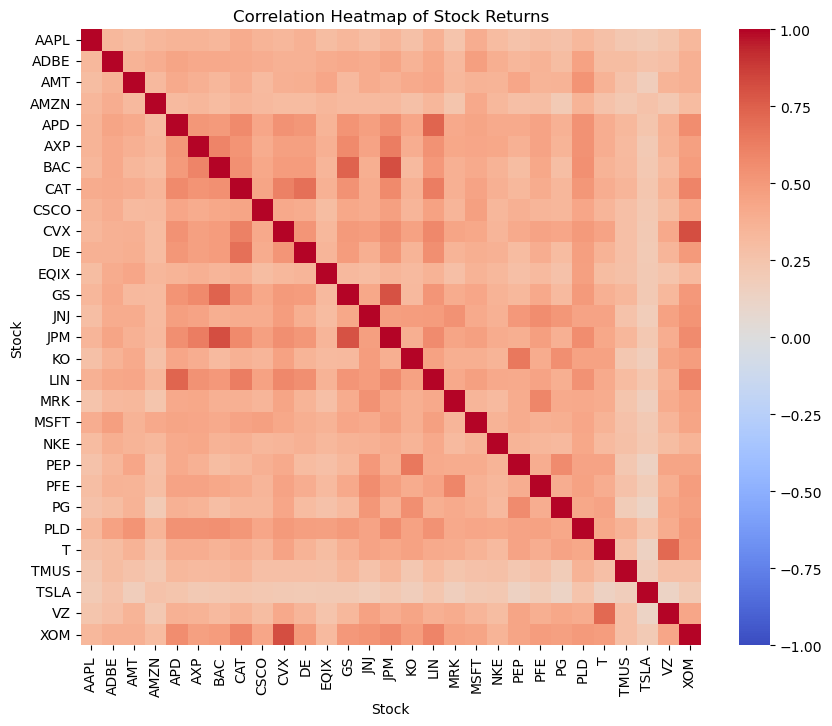

In [5]:
import seaborn as sns

# Split data
split_date = '2018-01-01'  
in_sample_returns = returns[:split_date]
out_sample_returns = returns[split_date:]

# Plot historical price trends
def plot_price_trends(data, filename='historical_price_trend.png'):
    plt.rcParams['figure.figsize'] = [18, 8]     
    data.plot()
    plt.title('Historical Price Trends')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight') 
    plt.show()

# Plot correlation heatmap
def plot_correlation_heatmap(returns,filename='correlation_heatmap.png'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(returns.corr(), annot=False, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title('Correlation Heatmap of Stock Returns')
    plt.savefig(filename, dpi=300, bbox_inches='tight')                          
    plt.show()
    
# Execute all visualizations and summaries
plot_price_trends(data)
plot_correlation_heatmap(in_sample_returns)

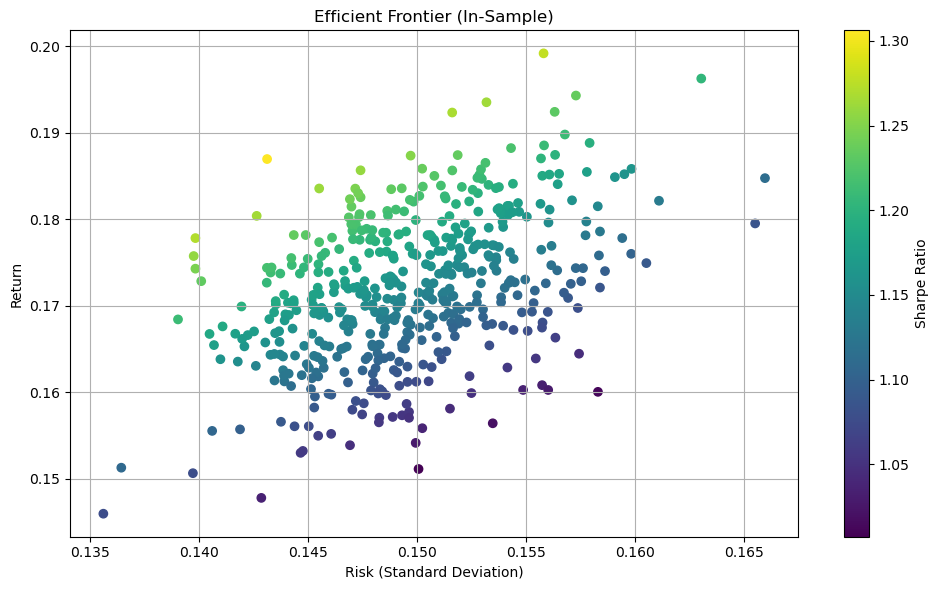

In [6]:
def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)

def portfolio_risk(weights, var_cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(var_cov_matrix, weights)))

def plot_efficient_frontier(returns, title):
    
    expected_returns = returns.mean() * 252  # Annualized returns
    var_cov_matrix = returns.cov() * 252  # Annualized covariance matrix

    frontier_returns = []
    frontier_risks = []

    # Simulate 500 porfolios
    for _ in range(500):
        weights = np.random.random(n_assets)
        weights /= np.sum(weights)
        r = portfolio_return(weights, expected_returns)
        risk = portfolio_risk(weights, var_cov_matrix)
        frontier_returns.append(r)
        frontier_risks.append(risk)

    # Efficient Frontier
    plt.figure(figsize=(10, 6))
    plt.scatter(frontier_risks, frontier_returns, c=np.array(frontier_returns) / np.array(frontier_risks), cmap='viridis', marker='o')
    plt.colorbar(label='Sharpe Ratio')
    plt.title(title)
    plt.xlabel('Risk (Standard Deviation)')
    plt.ylabel('Return')
    plt.grid()
    plt.tight_layout()
    
plot_efficient_frontier(in_sample_returns, 'Efficient Frontier (In-Sample)')

plt.show()

# Optimization

## Define optimization problem 

Optimized Portfolio (In-Sample):
Sharpe Ratio: 1.399
Expected Portfolio Return: 23.53%
Portfolio Risk (Standard Deviation): 15.39%

Optimal Weights for Each Stock:
AAPL: 19.14%
MSFT: 0.00%
ADBE: 7.31%
CSCO: 14.05%
JPM: 0.00%
BAC: 0.00%
GS: 0.00%
AXP: 0.00%
PG: 0.00%
KO: 0.00%
PEP: 0.00%
XOM: 3.48%
CVX: 0.00%
JNJ: 17.58%
PFE: 0.00%
MRK: 0.00%
AMZN: 0.00%
NKE: 0.00%
TSLA: 0.00%
T: 7.52%
VZ: 10.91%
TMUS: 0.00%
CAT: 0.00%
DE: 0.00%
APD: 0.00%
LIN: 3.96%
PLD: 10.82%
AMT: 5.23%
EQIX: 0.00%


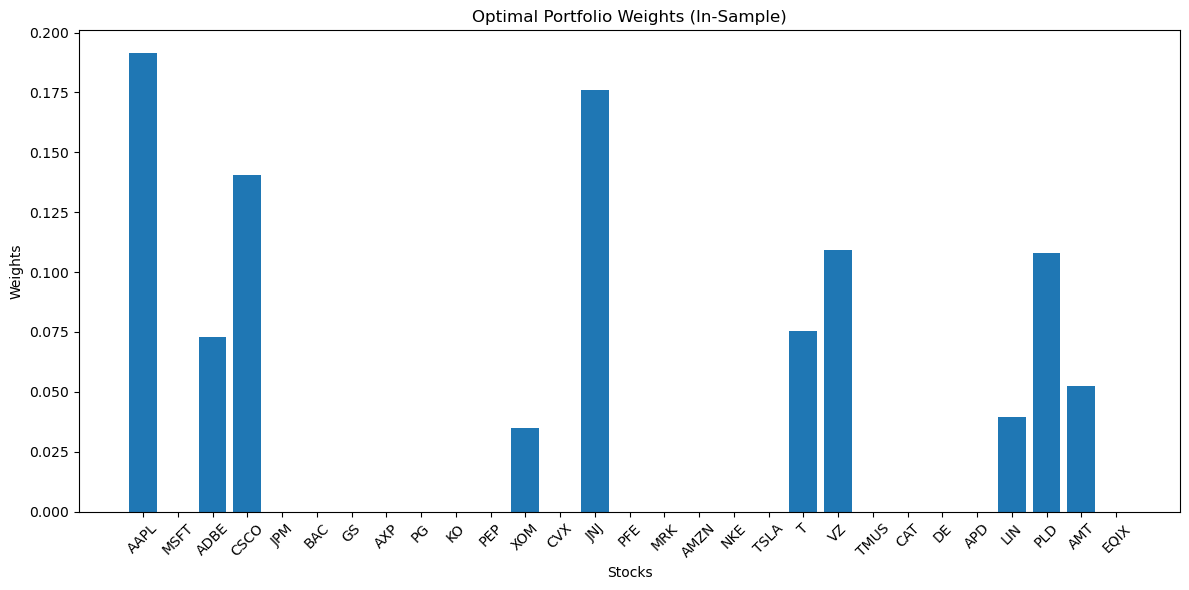

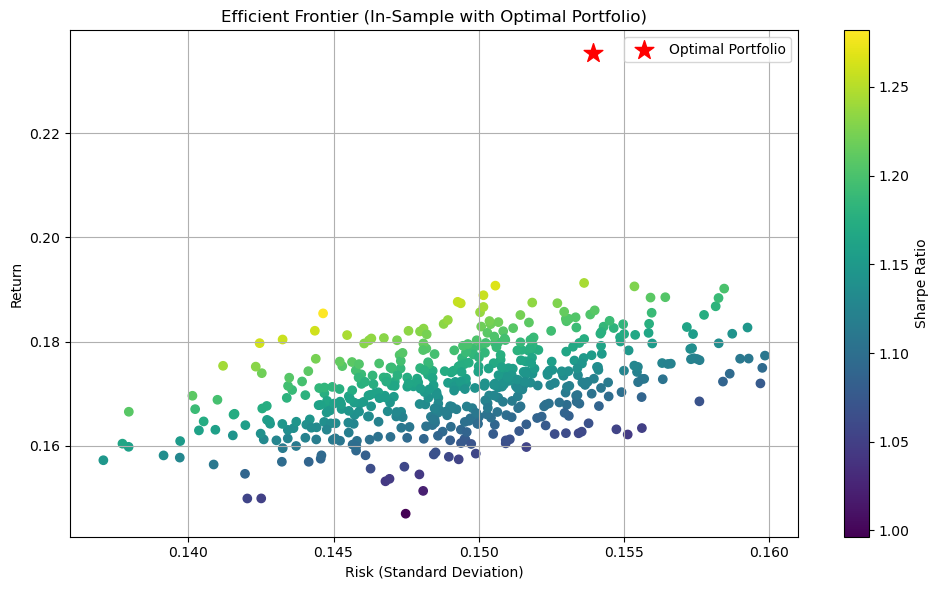

In [7]:
def sharpe_ratio(weights, expected_returns, var_cov_matrix, risk_free_rate):
    port_return = portfolio_return(weights, expected_returns)
    port_risk = portfolio_risk(weights, var_cov_matrix)
    return (port_return - risk_free_rate) / port_risk

def objective_sharpe(weights, expected_returns, var_cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, expected_returns, var_cov_matrix, risk_free_rate)  # Negative because we minimize

# constraint
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})  # Weights sum to 1
bounds = [(0, 0.2) for _ in range(n_assets)]  # No short selling, weight <= 20%

# optimize in sample
expected_returns_in = in_sample_returns.mean() * 252  # Annualized return
var_cov_matrix_in = in_sample_returns.cov() * 252  # Annualized covariance matrix
risk_free_rate = 0.02  # Risk-free rate (2%)

initial_weights = np.array([1 / n_assets] * n_assets)

result = minimize(
    objective_sharpe, 
    initial_weights, 
    args=(expected_returns_in, var_cov_matrix_in, risk_free_rate), 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

optimal_weights = result.x
optimal_sharpe_ratio = -result.fun
optimal_portfolio_return = portfolio_return(optimal_weights, expected_returns_in)
optimal_portfolio_risk = portfolio_risk(optimal_weights, var_cov_matrix_in)

print("Optimized Portfolio (In-Sample):")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.3f}")
print(f"Expected Portfolio Return: {optimal_portfolio_return:.2%}")
print(f"Portfolio Risk (Standard Deviation): {optimal_portfolio_risk:.2%}")
print("\nOptimal Weights for Each Stock:")
for ticker, weight in zip(STOCK_TICKERS, optimal_weights):
    print(f"{ticker}: {weight:.2%}")

def plot_optimal_weights(stock_tickers, optimal_weights):
    plt.figure(figsize=(12, 6))
    plt.bar(stock_tickers, optimal_weights)
    plt.title('Optimal Portfolio Weights (In-Sample)')
    plt.xlabel('Stocks')
    plt.ylabel('Weights')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('optimal_weight', dpi=300, bbox_inches='tight')
    plt.show()

plot_optimal_weights(STOCK_TICKERS, optimal_weights)

def plot_efficient_frontier_with_optimal(returns, optimal_weights, title):
    expected_returns = returns.mean() * 252
    var_cov_matrix = returns.cov() * 252

    frontier_returns = []
    frontier_risks = []

    for _ in range(500):
        weights = np.random.random(n_assets)
        weights /= np.sum(weights)
        r = portfolio_return(weights, expected_returns)
        risk = portfolio_risk(weights, var_cov_matrix)
        frontier_returns.append(r)
        frontier_risks.append(risk)

    optimal_r = portfolio_return(optimal_weights, expected_returns)
    optimal_risk = portfolio_risk(optimal_weights, var_cov_matrix)

    plt.figure(figsize=(10, 6))
    plt.scatter(frontier_risks, frontier_returns, c=np.array(frontier_returns) / np.array(frontier_risks), cmap='viridis', marker='o')
    plt.colorbar(label='Sharpe Ratio')
    plt.scatter(optimal_risk, optimal_r, color='red', label='Optimal Portfolio', marker='*', s=200)
    plt.title(title)
    plt.xlabel('Risk (Standard Deviation)')
    plt.ylabel('Return')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('efficient frontier', dpi=300, bbox_inches='tight')
    plt.show()

plot_efficient_frontier_with_optimal(in_sample_returns, optimal_weights, 'Efficient Frontier (In-Sample with Optimal Portfolio)')


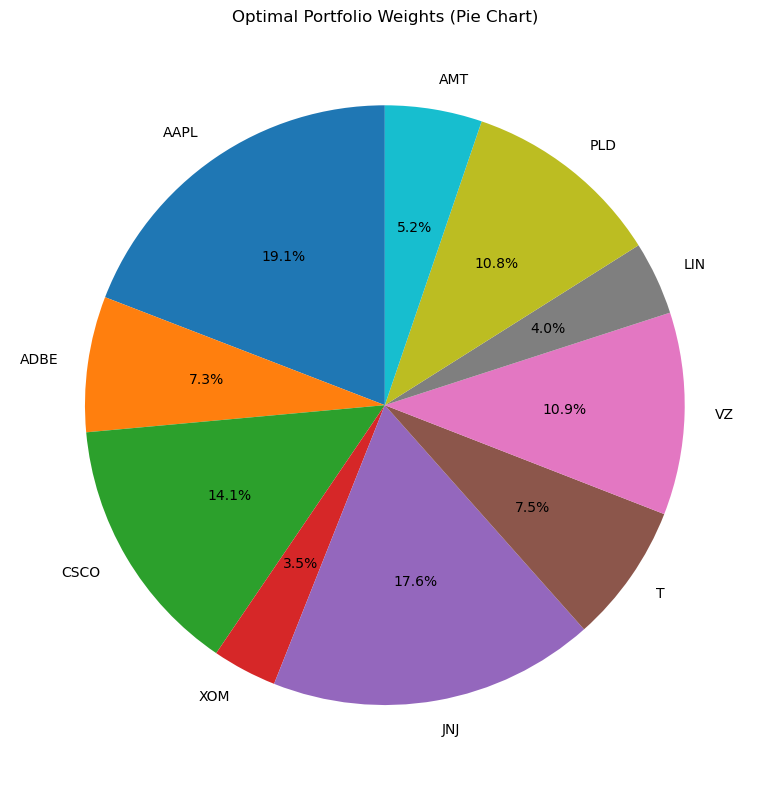

In [8]:
def plot_optimal_pie_chart(stock_tickers, optimal_weights):
    positive_weights = [(ticker, weight) for ticker, weight in zip(stock_tickers, optimal_weights) if weight > 0.02]
    
    positive_tickers = [item[0] for item in positive_weights]
    positive_values = [item[1] for item in positive_weights]
    
    plt.figure(figsize=(10, 8))
    plt.pie(
        positive_values, 
        labels=positive_tickers, 
        autopct='%1.1f%%', 
        startangle=90, 
        textprops={'fontsize': 10}
    )
    plt.title('Optimal Portfolio Weights (Pie Chart)')
    plt.tight_layout()
    plt.savefig('optimal_weights_pie_chart.png', dpi=300, bbox_inches='tight')  # Lưu biểu đồ
    plt.show()

plot_optimal_pie_chart(STOCK_TICKERS, optimal_weights)


## Benchmark

Out-of-Sample Performance:
Optimized Portfolio Sharpe Ratio: 1.404
Benchmark Portfolio Sharpe Ratio: 0.843

Cumulative Returns (Optimized Portfolio): 1.0514717631568606
Cumulative Returns (Benchmark Portfolio): 0.6455388693811104


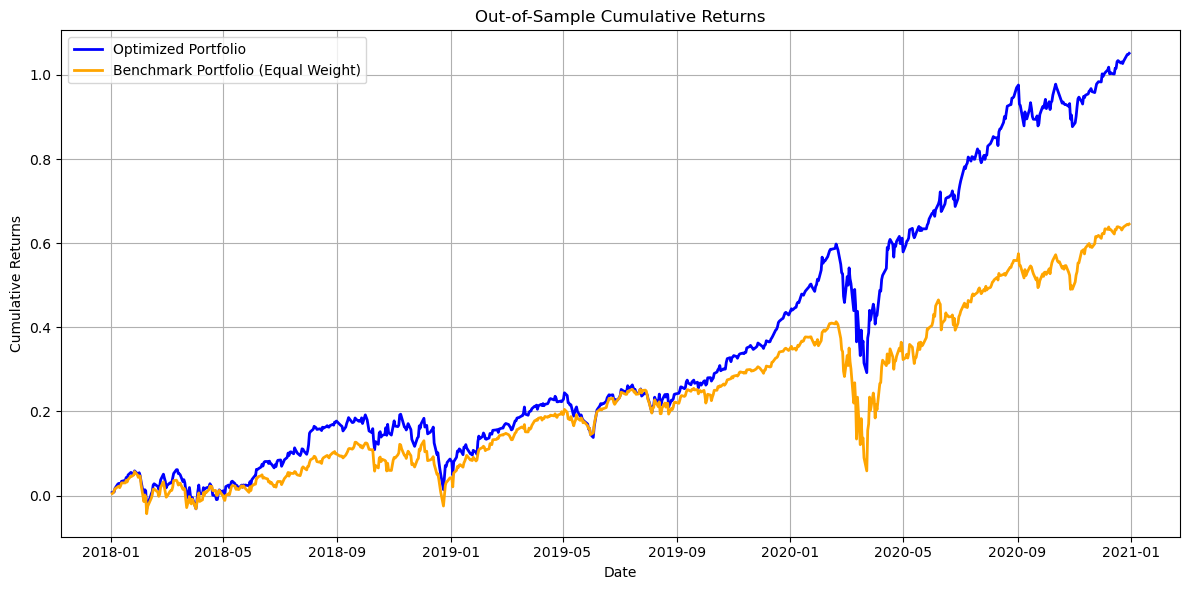

In [9]:
# use optimal weight on out sample
expected_returns_out = out_sample_returns.mean() * 252
var_cov_matrix_out = out_sample_returns.cov() * 252

optimized_portfolio_returns = np.dot(out_sample_returns, optimal_weights)
optimized_cumulative_returns = np.cumsum(optimized_portfolio_returns)

optimized_portfolio_mean_return = optimized_portfolio_returns.mean() * 252
optimized_portfolio_std = optimized_portfolio_returns.std() * np.sqrt(252)
optimized_portfolio_sharpe = (optimized_portfolio_mean_return - risk_free_rate) / optimized_portfolio_std

# benchmark equal weight
equal_weights = np.array([1 / n_assets] * n_assets)  # Trọng số bằng nhau
benchmark_returns = np.dot(out_sample_returns, equal_weights)
benchmark_cumulative_returns = np.cumsum(benchmark_returns)

benchmark_mean_return = benchmark_returns.mean() * 252
benchmark_std = benchmark_returns.std() * np.sqrt(252)
benchmark_sharpe = (benchmark_mean_return - risk_free_rate) / benchmark_std

print("Out-of-Sample Performance:")
print(f"Optimized Portfolio Sharpe Ratio: {optimized_portfolio_sharpe:.3f}")
print(f"Benchmark Portfolio Sharpe Ratio: {benchmark_sharpe:.3f}")
print("\nCumulative Returns (Optimized Portfolio):", optimized_cumulative_returns[-1])
print("Cumulative Returns (Benchmark Portfolio):", benchmark_cumulative_returns[-1])

def plot_performance_comparison(optimized_cumulative_returns, benchmark_cumulative_returns, dates):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, optimized_cumulative_returns, label='Optimized Portfolio', color='blue', linewidth=2)
    plt.plot(dates, benchmark_cumulative_returns, label='Benchmark Portfolio (Equal Weight)', color='orange', linewidth=2)
    plt.title('Out-of-Sample Cumulative Returns')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('peformance_analysis', dpi=300, bbox_inches='tight')
    plt.show()

plot_performance_comparison(
    optimized_cumulative_returns, 
    benchmark_cumulative_returns, 
    out_sample_returns.index
)

## Sensitivity analysis

Results of Sensitivity Analysis:
                    Scenario  Sharpe Ratio  Expected Return (%)   Risk (%)
0  Baseline (Current Inputs)      1.398898            23.532821  15.392699
1               Increased Rf      1.215807            26.426040  17.622898
2           Adjusted Returns      1.704831            27.914864  15.200843


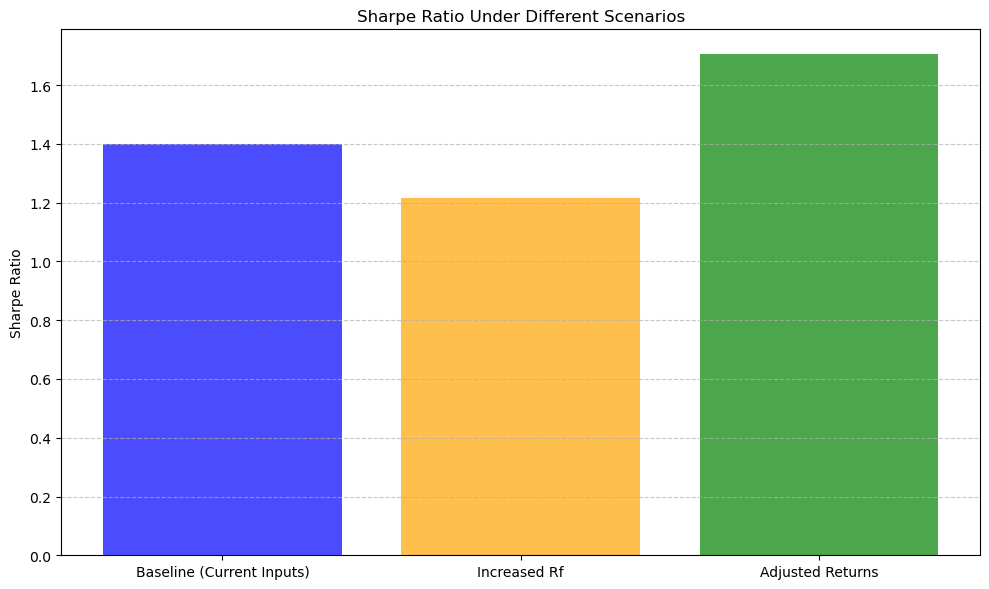

In [10]:
def optimize_portfolio(expected_returns, var_cov_matrix, risk_free_rate):
    result = minimize(
        objective_sharpe, 
        initial_weights, 
        args=(expected_returns, var_cov_matrix, risk_free_rate), 
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints
    )
    optimal_weights = result.x
    optimal_sharpe_ratio = -result.fun
    optimal_portfolio_return = portfolio_return(optimal_weights, expected_returns)
    optimal_portfolio_risk = portfolio_risk(optimal_weights, var_cov_matrix)
    return optimal_weights, optimal_sharpe_ratio, optimal_portfolio_return, optimal_portfolio_risk

# === BASELINE ===
baseline_weights, baseline_sharpe, baseline_return, baseline_risk = optimize_portfolio(
    expected_returns_in, var_cov_matrix_in, risk_free_rate
)

# === RISK-FREE RATE ===
increased_rf = 0.05  # Increase fisk-free rate
rf_weights, rf_sharpe, rf_return, rf_risk = optimize_portfolio(
    expected_returns_in, var_cov_matrix_in, increased_rf
)

# === E(R) ===
adjusted_returns = expected_returns_in * 1.2  # Increase expected return 20%
adjusted_weights, adjusted_sharpe, adjusted_return, adjusted_risk = optimize_portfolio(
    adjusted_returns, var_cov_matrix_in, risk_free_rate
)

# === SENSITIVITY ANALYSIS ===
results = pd.DataFrame({
    "Scenario": ["Baseline (Current Inputs)", "Increased Rf", "Adjusted Returns"],
    "Sharpe Ratio": [baseline_sharpe, rf_sharpe, adjusted_sharpe],
    "Expected Return (%)": [baseline_return * 100, rf_return * 100, adjusted_return * 100],
    "Risk (%)": [baseline_risk * 100, rf_risk * 100, adjusted_risk * 100]
})

print("Results of Sensitivity Analysis:")
print(results)

plt.figure(figsize=(10, 6))
x_labels = results["Scenario"]
plt.bar(x_labels, results["Sharpe Ratio"], color=['blue', 'orange', 'green'], alpha=0.7)
plt.title("Sharpe Ratio Under Different Scenarios")
plt.ylabel("Sharpe Ratio")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('sensitivity', dpi=300, bbox_inches='tight')
plt.show()

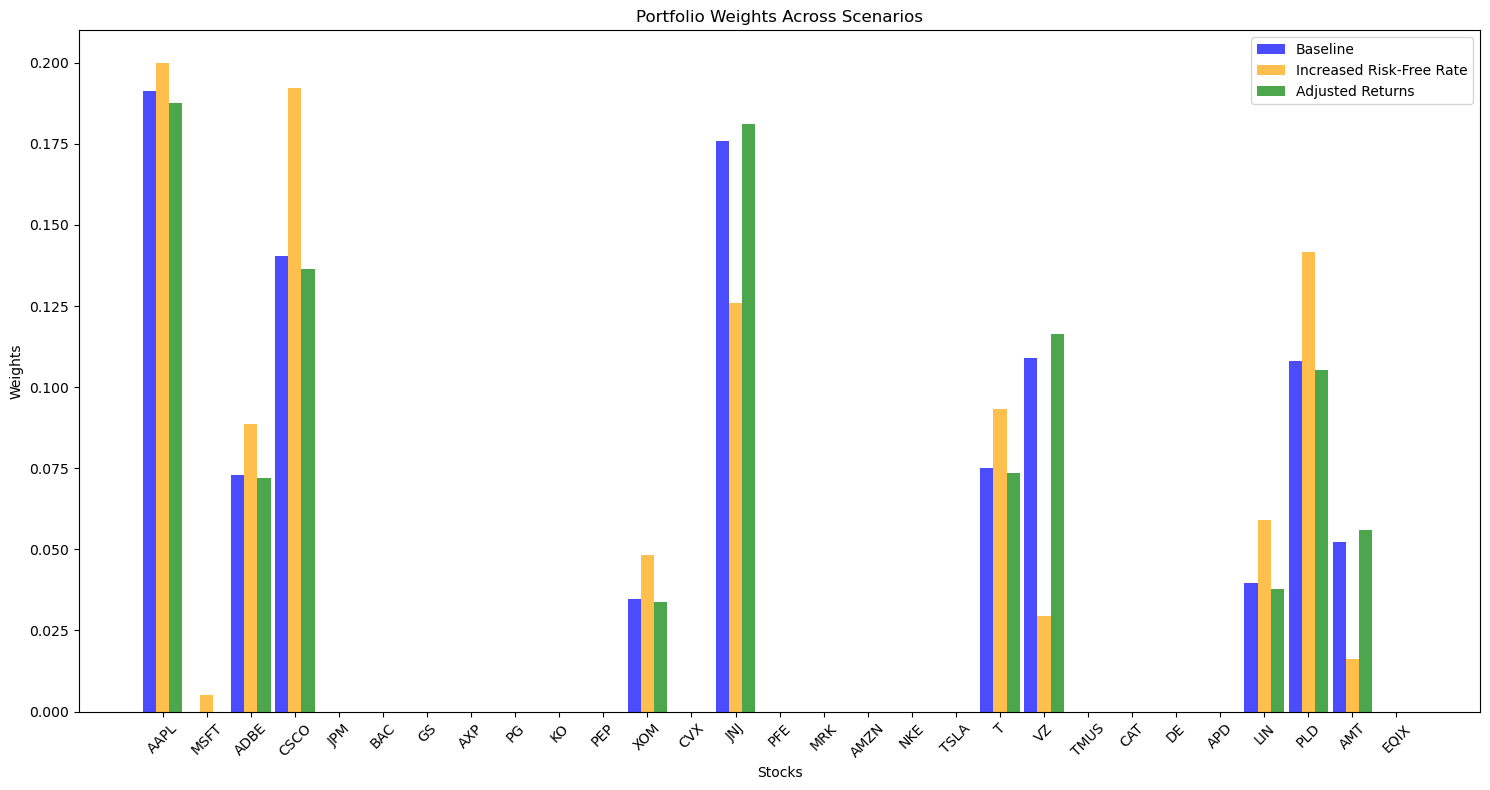

In [12]:
def plot_combined_scenario_weights(stock_tickers, baseline_weights, rf_weights, adjusted_weights):
    x = np.arange(len(stock_tickers))  
    width = 0.3  

    plt.figure(figsize=(15, 8))
    
    plt.bar(x - width, baseline_weights, width, label="Baseline", color='blue', alpha=0.7)
    plt.bar(x, rf_weights, width, label="Increased Risk-Free Rate", color='orange', alpha=0.7)
    plt.bar(x + width, adjusted_weights, width, label="Adjusted Returns", color='green', alpha=0.7)
    
    plt.title('Portfolio Weights Across Scenarios')
    plt.xlabel('Stocks')
    plt.ylabel('Weights')
    plt.xticks(x, stock_tickers, rotation=45, fontsize=10)  # Tên cổ phiếu trên trục x
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('sensitivity', dpi=300, bbox_inches='tight')
    plt.show()

plot_combined_scenario_weights(STOCK_TICKERS, baseline_weights, rf_weights, adjusted_weights)